# Coffee consumption and ranking 

Here is the link of the [dataset](https://www.kaggle.com/datasets/schmoyote/coffee-reviews-dataset?resource=download) 

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
df1 = pd.read_csv('coffee_analysis.csv')
df2 = pd.read_csv('simplified_coffee.csv')

In [3]:
display(df1.info(),df1.head())

<class 'pandas.DataFrame'>
RangeIndex: 2095 entries, 0 to 2094
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   name         2095 non-null   str    
 1   roaster      2095 non-null   str    
 2   roast        2080 non-null   str    
 3   loc_country  2095 non-null   str    
 4   origin_1     2095 non-null   str    
 5   origin_2     2095 non-null   str    
 6   100g_USD     2095 non-null   float64
 7   rating       2095 non-null   int64  
 8   review_date  2095 non-null   str    
 9   desc_1       2095 non-null   str    
 10  desc_2       2095 non-null   str    
 11  desc_3       2093 non-null   str    
dtypes: float64(1), int64(1), str(10)
memory usage: 196.5 KB


None

,name,roaster,roast,loc_country,origin_1,origin_2,100g_USD,rating,review_date,desc_1,desc_2,desc_3
0,“Sweety” Espresso Blend,A.R.C.,Medium-Light,Hong Kong,Panama,Ethiopia,14.32,95,November 2017,"Evaluated as espresso. Sweet-toned, deeply ric...",An espresso blend comprised of coffees from Pa...,A radiant espresso blend that shines equally i...
1,Flora Blend Espresso,A.R.C.,Medium-Light,Hong Kong,Africa,Asia Pacific,9.05,94,November 2017,"Evaluated as espresso. Sweetly tart, floral-to...",An espresso blend comprised of coffees from Af...,"A floral-driven straight shot, amplified with ..."
2,Ethiopia Shakiso Mormora,Revel Coffee,Medium-Light,United States,Guji Zone,Southern Ethiopia,4.70,92,November 2017,"Crisply sweet, cocoa-toned. Lemon blossom, roa...",This coffee tied for the third-highest rating ...,"A gently spice-toned, floral- driven wet-proce..."
3,Ethiopia Suke Quto,Roast House,Medium-Light,United States,Guji Zone,Oromia Region,4.19,92,November 2017,"Delicate, sweetly spice-toned. Pink peppercorn...",This coffee tied for the third-highest rating ...,Lavender-like flowers and hints of zesty pink ...
4,Ethiopia Gedeb Halo Beriti,Big Creek Coffee Roasters,Medium,United States,Gedeb District,Gedeo Zone,4.85,94,November 2017,"Deeply sweet, subtly pungent. Honey, pear, tan...",Southern Ethiopia coffees like this one are pr...,A deeply and generously lush cup saved from se...


In [4]:
display(df2.info(),df2.head())

<class 'pandas.DataFrame'>
RangeIndex: 1246 entries, 0 to 1245
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   name         1246 non-null   str    
 1   roaster      1246 non-null   str    
 2   roast        1234 non-null   str    
 3   loc_country  1246 non-null   str    
 4   origin       1246 non-null   str    
 5   100g_USD     1246 non-null   float64
 6   rating       1246 non-null   int64  
 7   review_date  1246 non-null   str    
 8   review       1246 non-null   str    
dtypes: float64(1), int64(1), str(7)
memory usage: 87.7 KB


None

,name,roaster,roast,loc_country,origin,100g_USD,rating,review_date,review
0,Ethiopia Shakiso Mormora,Revel Coffee,Medium-Light,United States,Ethiopia,4.70,92,November 2017,"Crisply sweet, cocoa-toned. Lemon blossom, roa..."
1,Ethiopia Suke Quto,Roast House,Medium-Light,United States,Ethiopia,4.19,92,November 2017,"Delicate, sweetly spice-toned. Pink peppercorn..."
2,Ethiopia Gedeb Halo Beriti,Big Creek Coffee Roasters,Medium,United States,Ethiopia,4.85,94,November 2017,"Deeply sweet, subtly pungent. Honey, pear, tan..."
3,Ethiopia Kayon Mountain,Red Rooster Coffee Roaster,Light,United States,Ethiopia,5.14,93,November 2017,"Delicate, richly and sweetly tart. Dried hibis..."
4,Ethiopia Gelgelu Natural Organic,Willoughby's Coffee & Tea,Medium-Light,United States,Ethiopia,3.97,93,November 2017,"High-toned, floral. Dried apricot, magnolia, a..."


In [5]:
roast = df1.groupby('roast')['rating'].mean().sort_values(ascending=False).reset_index()
display(roast)

,roast,rating
0,Light,93.522648
1,Medium-Light,93.226174
2,Medium,92.274131
3,Medium-Dark,91.871795
4,Dark,88.200000


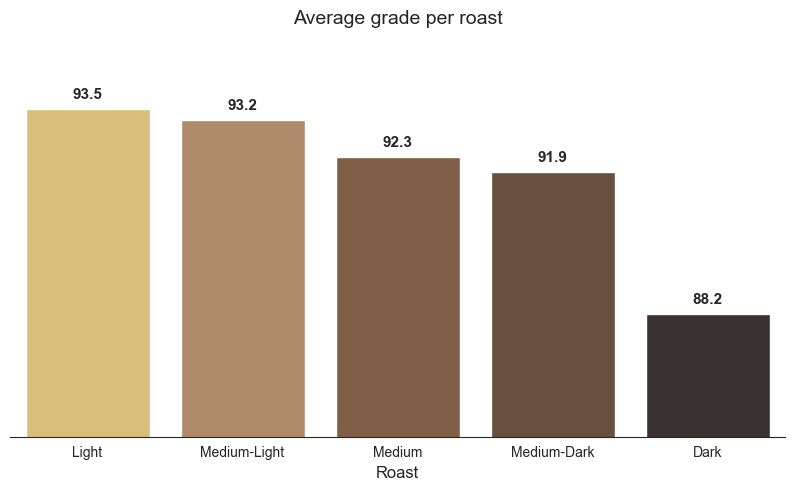

In [8]:
plt.figure(figsize=(10, 5))
sns.set_style("white") # Style très épuré sans grille

coffee_palette = {
    'Light': '#E9C46A',          # Doré / Blond
    'Medium-Light': '#BC8A5F',   # Cannelle / Brun clair
    'Medium': '#8B5E3C',         # Brun moyen
    'Medium-Dark': '#6F4E37',    # Café classique
    'Dark': '#3C2F2F'            # Chocolat noir / Brûlé
}

ax = sns.barplot(data=roast, x='roast', y='rating', palette=coffee_palette, hue='roast')

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f', padding=5, fontsize=11, fontweight='bold')

plt.ylim(85,95)

plt.title('Average grade per roast', fontsize=14, pad=20)
plt.xlabel('Roast', fontsize=12)

ax.get_yaxis().set_visible(False) 
sns.despine(left=True) 

plt.show()

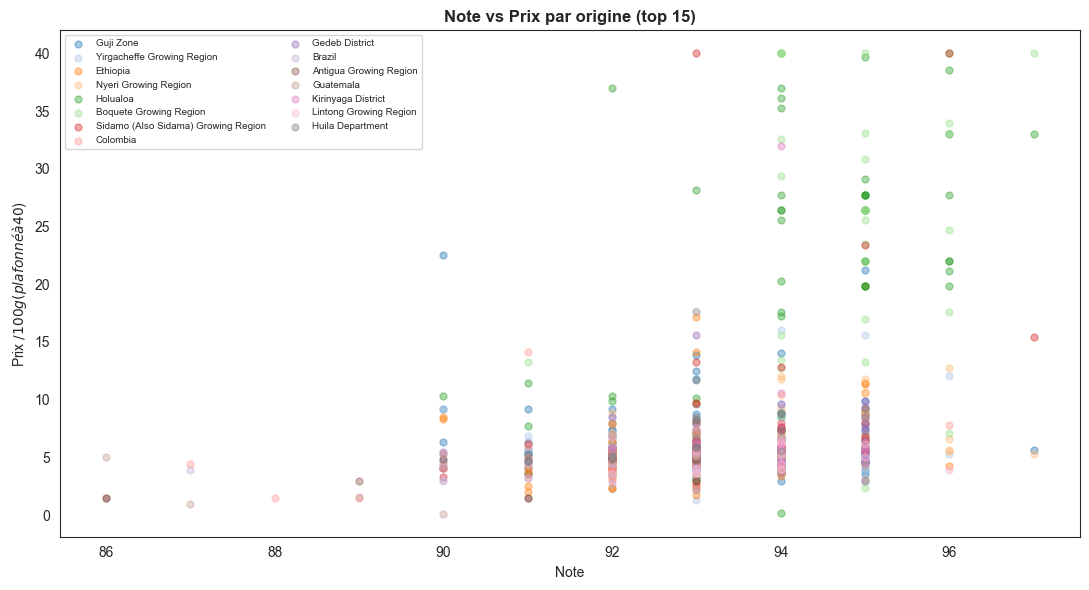

In [15]:
top_origins = df1['origin_1'].value_counts().head(15).index
df_orig = df1[df1['origin_1'].isin(top_origins)]

palette_orig = dict(zip(top_origins, sns.color_palette('tab20', len(top_origins))))

fig, ax = plt.subplots(figsize=(11, 6))

for orig in top_origins:
    sub = df_orig[df_orig['origin_1'] == orig]
    ax.scatter(sub['rating'], sub['100g_USD'].clip(upper=40),
               alpha=0.4, s=25, label=orig, color=palette_orig[orig])

ax.set_title('Note vs Prix par origine (top 15)', fontweight='bold')
ax.set_xlabel('Note')
ax.set_ylabel('Prix $/100g (plafonné à 40$)')
ax.legend(fontsize=7, ncol=2, loc='upper left', framealpha=0.8)

plt.tight_layout()
plt.show()

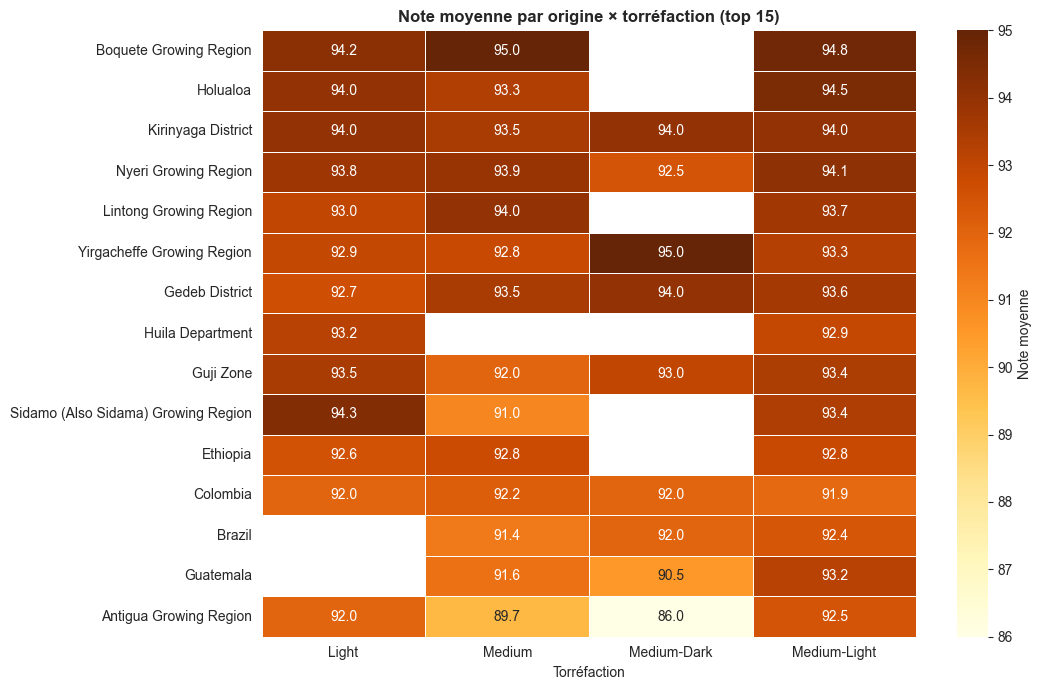

In [16]:
top_origins = df1['origin_1'].value_counts().head(15).index
df_orig = df1[df1['origin_1'].isin(top_origins)].dropna(subset=['roast'])

pivot = df_orig.pivot_table(
    values='rating',
    index='origin_1',
    columns='roast',
    aggfunc='mean',
    observed=True
)
# Trier les origines par note moyenne globale
pivot = pivot.loc[pivot.mean(axis=1).sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(11, 7))

sns.heatmap(
    pivot,
    annot=True,
    fmt='.1f',
    cmap='YlOrBr',
    ax=ax,
    linewidths=0.5,
    cbar_kws={'label': 'Note moyenne'},
    mask=pivot.isna()  # cases vides masquées
)

ax.set_title('Note moyenne par origine × torréfaction (top 15)', fontweight='bold')
ax.set_xlabel('Torréfaction')
ax.set_ylabel('')

plt.tight_layout()
plt.show()

In [18]:
df1['review_date'] = pd.to_datetime(df1['review_date'], format='%B %Y')
df1['year_month'] = df1['review_date'].dt.to_period('M')
df1['year'] = df1['review_date'].dt.year

display(df1.head())

,name,roaster,roast,loc_country,origin_1,origin_2,100g_USD,rating,review_date,desc_1,desc_2,desc_3,year_month,year
0,“Sweety” Espresso Blend,A.R.C.,Medium-Light,Hong Kong,Panama,Ethiopia,14.32,95,2017-11-01,"Evaluated as espresso. Sweet-toned, deeply ric...",An espresso blend comprised of coffees from Pa...,A radiant espresso blend that shines equally i...,2017-11,2017
1,Flora Blend Espresso,A.R.C.,Medium-Light,Hong Kong,Africa,Asia Pacific,9.05,94,2017-11-01,"Evaluated as espresso. Sweetly tart, floral-to...",An espresso blend comprised of coffees from Af...,"A floral-driven straight shot, amplified with ...",2017-11,2017
2,Ethiopia Shakiso Mormora,Revel Coffee,Medium-Light,United States,Guji Zone,Southern Ethiopia,4.70,92,2017-11-01,"Crisply sweet, cocoa-toned. Lemon blossom, roa...",This coffee tied for the third-highest rating ...,"A gently spice-toned, floral- driven wet-proce...",2017-11,2017
3,Ethiopia Suke Quto,Roast House,Medium-Light,United States,Guji Zone,Oromia Region,4.19,92,2017-11-01,"Delicate, sweetly spice-toned. Pink peppercorn...",This coffee tied for the third-highest rating ...,Lavender-like flowers and hints of zesty pink ...,2017-11,2017
4,Ethiopia Gedeb Halo Beriti,Big Creek Coffee Roasters,Medium,United States,Gedeb District,Gedeo Zone,4.85,94,2017-11-01,"Deeply sweet, subtly pungent. Honey, pear, tan...",Southern Ethiopia coffees like this one are pr...,A deeply and generously lush cup saved from se...,2017-11,2017


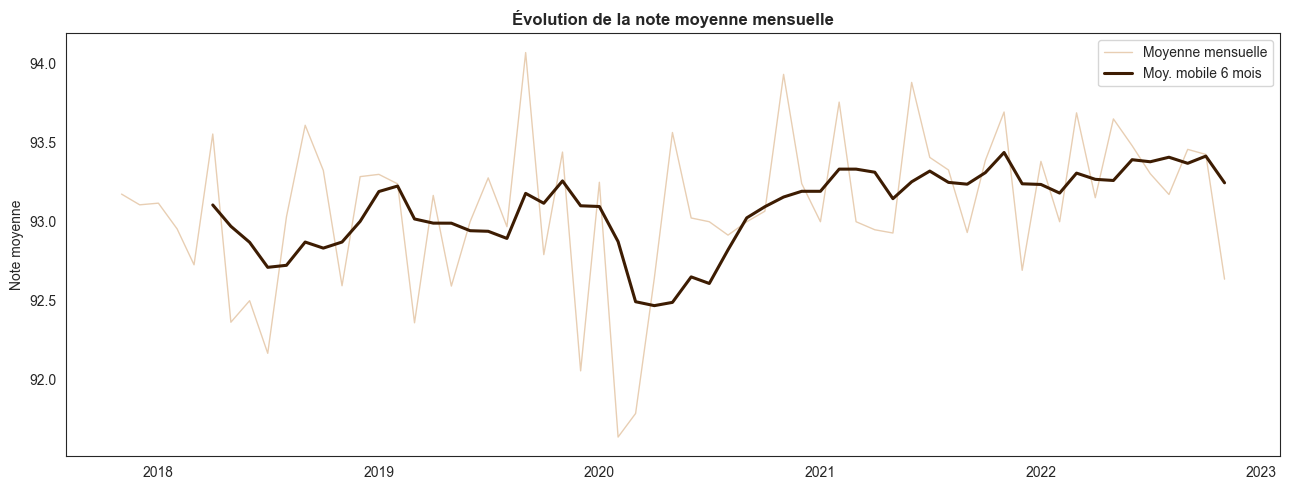

In [19]:
monthly = df1.groupby('year_month')['rating'].agg(['mean', 'count'])
monthly.index = monthly.index.to_timestamp()

fig, ax = plt.subplots(figsize=(13, 5))

ax.plot(monthly.index, monthly['mean'], color='#c68642', linewidth=1, alpha=0.4, label='Moyenne mensuelle')
ax.plot(monthly.index, monthly['mean'].rolling(6).mean(), color='#3d1c02', linewidth=2.2, label='Moy. mobile 6 mois')

ax.set_title('Évolution de la note moyenne mensuelle', fontweight='bold')
ax.set_ylabel('Note moyenne')
ax.set_xlabel('')
ax.legend()

plt.tight_layout()
plt.show()

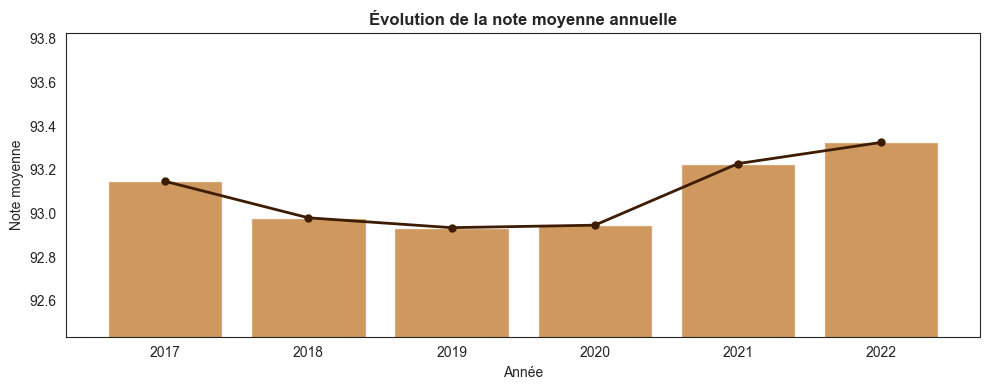

In [20]:
yearly = df1.groupby('year')['rating'].mean()

fig, ax = plt.subplots(figsize=(10, 4))

ax.bar(yearly.index, yearly.values, color='#c68642', alpha=0.85, edgecolor='white')
ax.plot(yearly.index, yearly.values, color='#3d1c02', linewidth=2, marker='o', markersize=5)

ax.set_title('Évolution de la note moyenne annuelle', fontweight='bold')
ax.set_ylabel('Note moyenne')
ax.set_xlabel('Année')
ax.set_ylim(yearly.min() - 0.5, yearly.max() + 0.5)

plt.tight_layout()
plt.show()

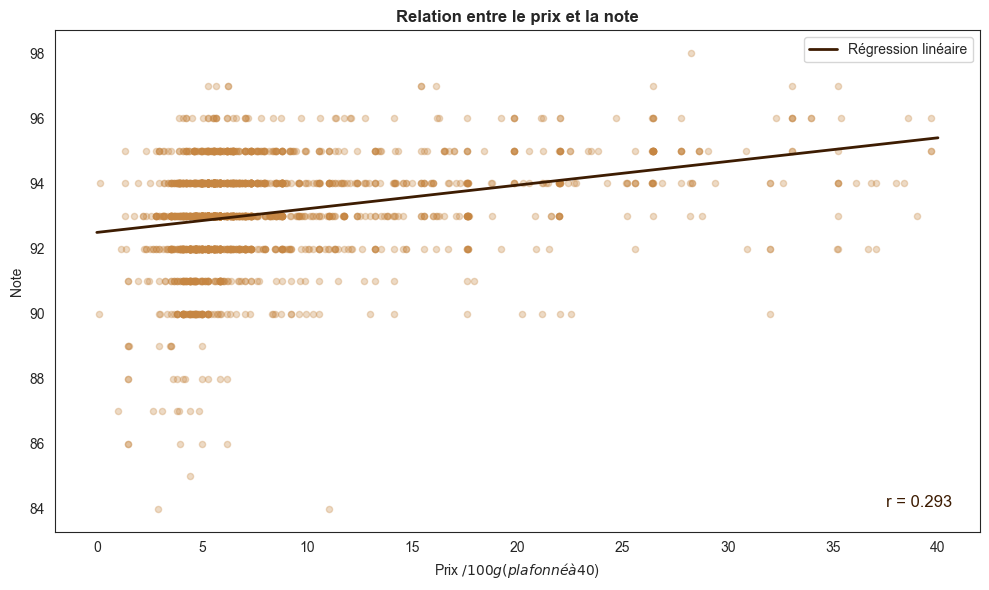

In [23]:
fig, ax = plt.subplots(figsize=(10, 6))

df_clip = df1[df1['100g_USD'] <= 40]

ax.scatter(df_clip['100g_USD'], df_clip['rating'], alpha=0.3, s=20, color='#c68642')

# Ligne de régression
z = np.polyfit(df_clip['100g_USD'], df_clip['rating'], 1)
p = np.poly1d(z)
x_line = np.linspace(0, 40, 100)
ax.plot(x_line, p(x_line), color='#3d1c02', linewidth=2, label=f'Régression linéaire')

# Corrélation
corr = df_clip[['100g_USD', 'rating']].corr().iloc[0, 1]
ax.text(0.97, 0.05, f'r = {corr:.3f}', transform=ax.transAxes,
        ha='right', fontsize=12, color='#3d1c02',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='none', alpha=0.8))

ax.set_title('Relation entre le prix et la note', fontweight='bold')
ax.set_xlabel('Prix $/100g (plafonné à 40$)')
ax.set_ylabel('Note')
ax.legend()

plt.tight_layout()
plt.show()

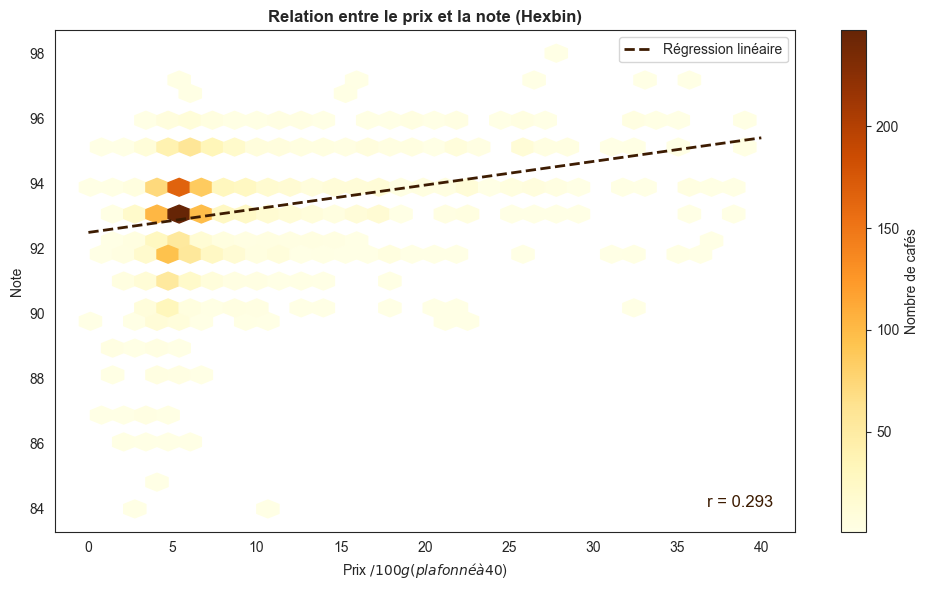

In [24]:
fig, ax = plt.subplots(figsize=(10, 6))

df_clip = df1[df1['100g_USD'] <= 40]

hb = ax.hexbin(df_clip['100g_USD'], df_clip['rating'],
               gridsize=30, cmap='YlOrBr', mincnt=1)

# Colorbar
cb = fig.colorbar(hb, ax=ax)
cb.set_label('Nombre de cafés')

# Ligne de régression
z = np.polyfit(df_clip['100g_USD'], df_clip['rating'], 1)
p = np.poly1d(z)
x_line = np.linspace(0, 40, 100)
ax.plot(x_line, p(x_line), color='#3d1c02', linewidth=2, linestyle='--', label='Régression linéaire')

# Corrélation
corr = df_clip[['100g_USD', 'rating']].corr().iloc[0, 1]
ax.text(0.97, 0.05, f'r = {corr:.3f}', transform=ax.transAxes,
        ha='right', fontsize=12, color='#3d1c02',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='none', alpha=0.8))

ax.set_title('Relation entre le prix et la note (Hexbin)', fontweight='bold')
ax.set_xlabel('Prix $/100g (plafonné à 40$)')
ax.set_ylabel('Note')
ax.legend()

plt.tight_layout()
plt.show()